# Fourier Descriptors

In [166]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

## Corner Extraction

In [167]:
# ============================================================
# Paths
# ============================================================

BASE_DIR = Path.cwd()

CARDS_DIR = BASE_DIR / "cards"

IMAGE_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
}

In [88]:
# ============================================================
# Parameters
# ============================================================

# Fraction of card size used for the corner crop
CORNER_WIDTH_RATIO = 0.33
CORNER_HEIGHT_RATIO = 0.17

# Display count
MAX_PREVIEW = 12

In [89]:
# ============================================================
# Utilities
# ============================================================

def load_card_images(cards_dir: Path):

    paths = sorted(
        path for path in cards_dir.iterdir()
        if path.suffix.lower() in IMAGE_EXTENSIONS
    )

    images = []

    for path in paths:

        image_bgr = cv2.imread(str(path))

        if image_bgr is None:
            print(f"Skipping unreadable image: {path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        images.append((path.name, image_rgb))

    return images


def extract_top_left_corner(card_rgb: np.ndarray):

    height, width = card_rgb.shape[:2]

    corner_w = int(width * CORNER_WIDTH_RATIO)
    corner_h = int(height * CORNER_HEIGHT_RATIO)

    corner = card_rgb[
        0:corner_h,
        0:corner_w
    ]

    return corner


def extract_bottom_right_corner(card_rgb: np.ndarray):

    height, width = card_rgb.shape[:2]

    corner_w = int(width * CORNER_WIDTH_RATIO)
    corner_h = int(height * CORNER_HEIGHT_RATIO)

    corner = card_rgb[
        height - corner_h:height,
        width - corner_w:width
    ]

    # rotate 180 degrees so symbols are upright
    corner = cv2.rotate(corner, cv2.ROTATE_180)

    return corner


def show_corner_extraction(cards):

    preview_cards = cards[:MAX_PREVIEW]

    rows = len(preview_cards)

    fig, axes = plt.subplots(
        rows,
        3,
        figsize=(12, 4 * rows)
    )

    if rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_axes, (name, card_rgb) in zip(axes, preview_cards):

        top_left = extract_top_left_corner(card_rgb)

        bottom_right = extract_bottom_right_corner(card_rgb)

        row_axes[0].imshow(card_rgb)
        row_axes[0].set_title(name)
        row_axes[0].axis("off")

        row_axes[1].imshow(top_left)
        row_axes[1].set_title("Top-left ROI")
        row_axes[1].axis("off")

        row_axes[2].imshow(bottom_right)
        row_axes[2].set_title("Bottom-right ROI")
        row_axes[2].axis("off")

    plt.tight_layout()
    plt.show()

Loaded 54 cards


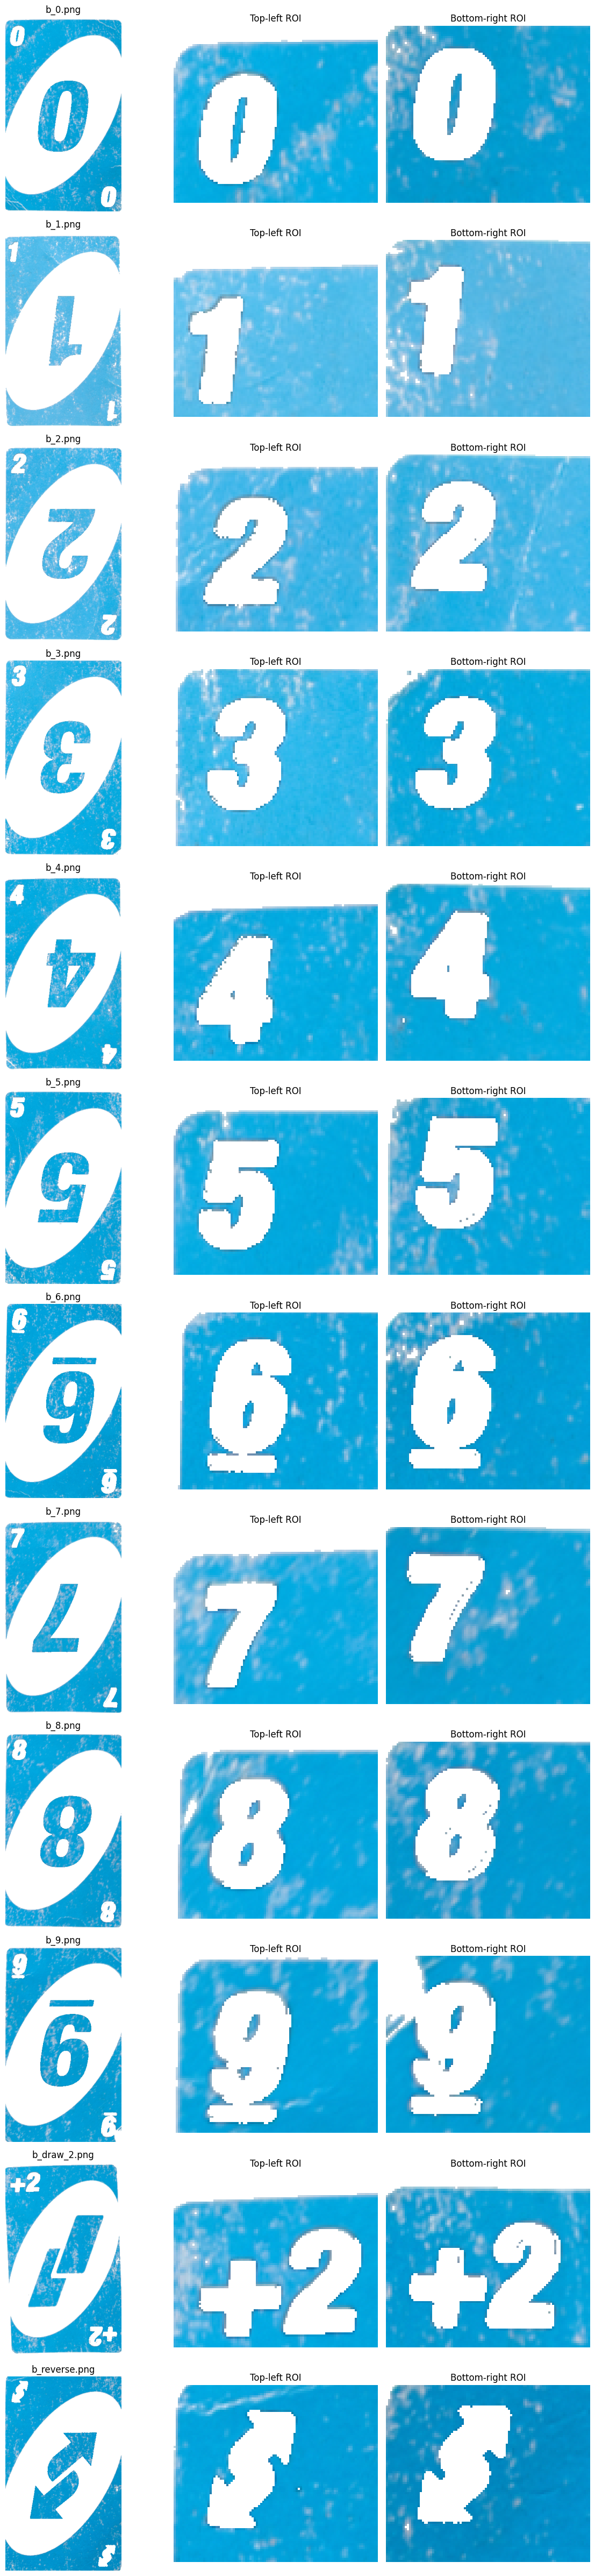

In [90]:
# ============================================================
# Run
# ============================================================

cards = load_card_images(CARDS_DIR)

print(f"Loaded {len(cards)} cards")

show_corner_extraction(cards)

## Threshold + morphology preprocessing of the corners for Fourier descriptors later

In [91]:
# Display helper

def show(img, title="Image", cmap="gray"):
    plt.figure(figsize=(4,4))
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

`preprocess_symbol`:

* converts to grayscale
* thresholds the image
* cleans noise with morphology
* returns a clean binary image

In [92]:
def dynamic_corner_crop(roi, threshold=200, step=1):
    """
    Dynamically crops top-left border by scanning inward until
    pixel intensity stops matching border/background.

    Args
    ----
    roi : np.ndarray
        Corner image
    threshold : int
        Brightness threshold for "border-like" pixels
    step : int
        scanning step size

    Returns
    -------
    cropped : np.ndarray
    """

    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape

    # ---- find top boundary ----
    top = 0
    for i in range(h):
        row_mean = np.mean(gray[i, :])
        if row_mean < threshold:  # entered "content"
            top = i
            break

    # ---- find left boundary ----
    left = 0
    for j in range(w):
        col_mean = np.mean(gray[:, j])
        if col_mean < threshold:
            left = j
            break

    # keep full bottom/right (safe)
    cropped = roi[top:, left:]

    # remove remaining top-left artifact
    h, w = cropped.shape[:2]
    cropped = cropped[int(0.1*h):, int(0.1*w):]

    return cropped

In [93]:
def preprocess_symbol(roi):
    """
    Preprocess UNO corner ROI for contour extraction.

    Args
    ----
    roi : np.ndarray
        Corner ROI image

    Returns
    -------
    cleaned : np.ndarray
        Binary cleaned image
    """

    # Convert to grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)

    # Blur to reduce noise
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # Threshold
    # White symbol becomes white, background black
    _, thresh = cv2.threshold(
        blur,
        220,                # adjust manually
        255,
        cv2.THRESH_BINARY
    )

    # Morphological kernels
    kernel = np.ones((3,3), np.uint8)

    # Opening = remove tiny noise
    opened = cv2.morphologyEx(
        thresh,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )
    
    #Closing = fill small holes
    cleaned = cv2.morphologyEx(
        opened,
       cv2.MORPH_CLOSE,
       kernel,
       iterations=1
    )

    return cleaned

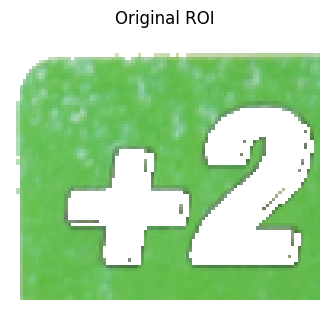

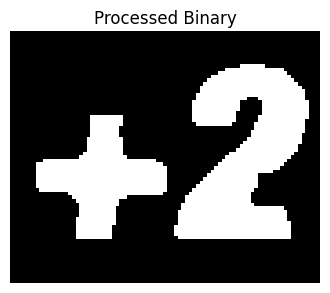

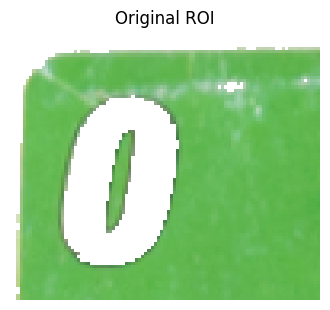

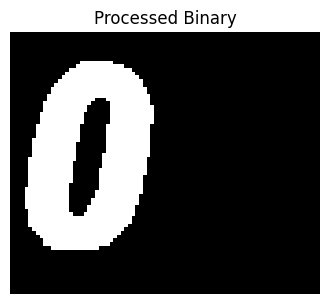

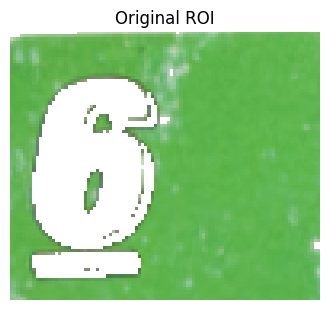

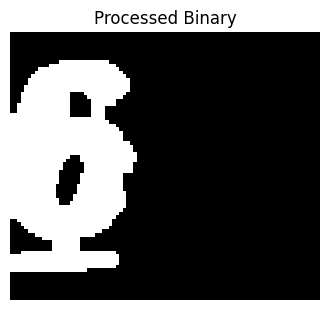

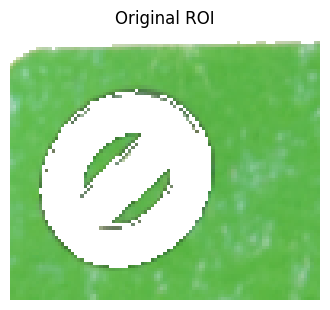

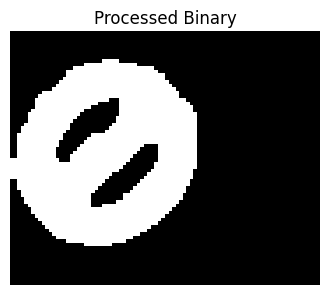

In [95]:
# ============================================================
# Test preprocessing on one card corner
# ============================================================

# Take first loaded card
card_name, card_rgb = cards[24]
card_name_2, card_rgb_2 = cards[14]
card_name_3, card_rgb_3 = cards[20]
card_name_4, card_rgb_4 = cards[26]

# Extract one corner ROI
roi = extract_top_left_corner(card_rgb)
roi2 = extract_top_left_corner(card_rgb_2)
roi3 = extract_top_left_corner(card_rgb_3)
roi4 = extract_top_left_corner(card_rgb_4)

# Optional resize for consistency
#roi = cv2.resize(roi, (128, 128))

cropped = dynamic_corner_crop(roi, threshold=200, step=1)
cropped2 = dynamic_corner_crop(roi2, threshold=200, step=1)
cropped3 = dynamic_corner_crop(roi3, threshold=200, step=1)
cropped4 = dynamic_corner_crop(roi4, threshold=200, step=1)

# Preprocess
processed = preprocess_symbol(cropped)
processed2 = preprocess_symbol(cropped2)
processed3 = preprocess_symbol(cropped3)
processed4 = preprocess_symbol(cropped4)

# Display
show(roi, "Original ROI", cmap=None)
show(processed, "Processed Binary")

show(roi2, "Original ROI", cmap=None)
show(processed2, "Processed Binary")

show(roi3, "Original ROI", cmap=None)
show(processed3, "Processed Binary")

show(roi4, "Original ROI", cmap=None)
show(processed4, "Processed Binary")

## Contour extraction

In [85]:
def find_contour_uno(binary_img, min_ratio=0.01):
    """
    Robust contour extraction using relative area filtering.
    """

    img = binary_img.astype(np.uint8)
    h, w = img.shape[:2]
    img_area = h * w

    contours, _ = cv2.findContours(
        img,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_NONE
    )

    if len(contours) == 0:
        return np.array([])

    # -----------------------------------------
    # Keep only meaningful contours
    # -----------------------------------------
    filtered = []
    for c in contours:
        area = cv2.contourArea(c)

        if area > min_ratio * img_area:
            filtered.append(c)

    if len(filtered) == 0:
        return np.array([])

    # -----------------------------------------
    # Merge remaining contours
    # -----------------------------------------
    merged = np.vstack(filtered)
    coords = merged[:, 0, :]

    # normalize start point
    start_idx = np.argmin(coords[:, 0] + coords[:, 1])
    coords = np.roll(coords, -start_idx, axis=0)

    return coords

In [86]:
contour = find_contour_uno(processed)
contour2 = find_contour_uno(processed2)
contour3 = find_contour_uno(processed3)
contour4 = find_contour_uno(processed4)

print(contour.shape)

(310, 2)


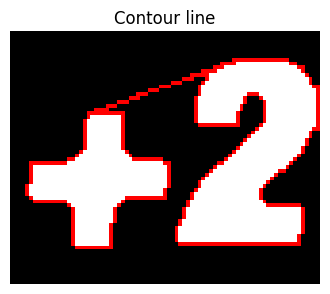

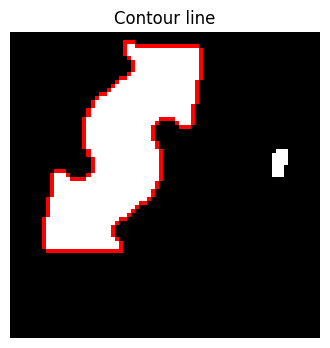

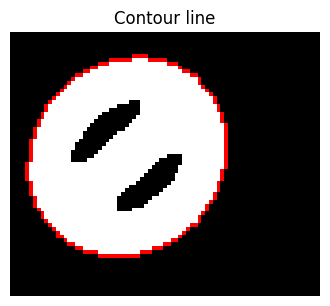

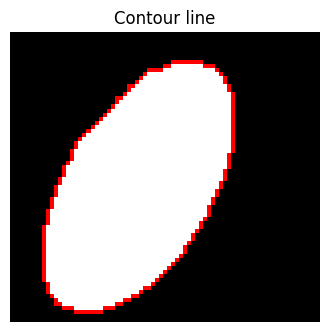

In [87]:
# convert for OpenCV drawing
img_vis = cv2.cvtColor(processed, cv2.COLOR_GRAY2BGR)
img_vis2 = cv2.cvtColor(processed2, cv2.COLOR_GRAY2BGR)
img_vis3 = cv2.cvtColor(processed3, cv2.COLOR_GRAY2BGR)
img_vis4 = cv2.cvtColor(processed4, cv2.COLOR_GRAY2BGR)

# reshape back to OpenCV format (K,1,2)
contour_cv = contour.reshape(-1, 1, 2)
contour_cv2 = contour2.reshape(-1, 1, 2)
contour_cv3 = contour3.reshape(-1, 1, 2)
contour_cv4 = contour4.reshape(-1, 1, 2)

# draw contour as a continuous red line
cv2.drawContours(
    img_vis,
    [contour_cv],
    -1,
    (255, 0, 0),   # red in BGR
    1              # thickness
)

cv2.drawContours(
    img_vis2,
    [contour_cv2],
    -1,
    (255, 0, 0),   # red in BGR
    1              # thickness
)

cv2.drawContours(
    img_vis3,
    [contour_cv3],
    -1,
    (255, 0, 0),   # red in BGR
    1              # thickness
)

cv2.drawContours(
    img_vis4,
    [contour_cv4],
    -1,
    (255, 0, 0),   # red in BGR
    1              # thickness
)

show(img_vis, "Contour line", cmap=None)
show(img_vis2, "Contour line", cmap=None)
show(img_vis3, "Contour line", cmap=None)
show(img_vis4, "Contour line", cmap=None)

## Fourier

select dataset (cards 13–26 + 40) -> les cartes vertes + les 2 cartes noires

In [111]:
selected_indices = list(range(13, 27)) + [40]

selected_cards = [cards[i] for i in selected_indices]

In [112]:
#full preprocessing + contour extraction

def build_contours(cards_subset):

    contours = []
    labels = []

    for name, card_rgb in cards_subset:

        roi = extract_top_left_corner(card_rgb)
        cropped = dynamic_corner_crop(roi, threshold=200)

        processed = preprocess_symbol(cropped)

        contour = find_contour_uno(processed)

        if contour.size == 0:
            continue

        contours.append(contour)
        labels.append(name)

    return contours, labels


contours, labels = build_contours(selected_cards)

Linear interpolation

In [113]:
def normalize_contour(contour, img_shape):
    """
    Fix coordinate system + center shape for FFT stability
    """

    contour = contour.copy()

    # flip Y axis (image → math convention)
    h = img_shape[0]
    contour[:, 1] = h - contour[:, 1]

    # center (remove translation invariance)
    contour = contour - np.mean(contour, axis=0)

    return contour

In [114]:
def resample_contour(contour, n_points=128):

    contour = np.asarray(contour)

    x = contour[:, 0]
    y = contour[:, 1]

    dx = np.diff(x)
    dy = np.diff(y)
    dist = np.sqrt(dx**2 + dy**2)

    t = np.concatenate([[0], np.cumsum(dist)])

    if t[-1] == 0:
        return np.zeros((n_points, 2))

    t = t / t[-1]

    t_new = np.linspace(0, 1, n_points)

    x_new = np.interp(t_new, t, x)
    y_new = np.interp(t_new, t, y)

    return np.stack([x_new, y_new], axis=1)

Fourier descriptors

In [115]:
def fourier_descriptors(contour, n_points=128, n_coeffs=20):

    # resample
    contour_rs = resample_contour(contour, n_points)

    # complex signal
    z = contour_rs[:, 0] + 1j * contour_rs[:, 1]

    # FFT
    F = np.fft.fft(z)

    # keep low frequencies symmetrically
    F_filtered = np.zeros_like(F)

    half = n_coeffs // 2

    F_filtered[:half] = F[:half]
    F_filtered[-half:] = F[-half:]

    return F_filtered

In [116]:
def reconstruct(F_filtered):
    return np.fft.ifft(F_filtered)

In [117]:
n_points = 128
n_coeffs = 20

descriptors = []
clean_contours = []

for contour in contours:

    # normalize
    contour_n = normalize_contour(contour, processed.shape)

    # store for visualization
    clean_contours.append(contour_n)

    # descriptor
    F = fourier_descriptors(contour_n, n_points, n_coeffs)

    descriptors.append(F)

descriptors = np.array(descriptors)

Visual Checks

In [120]:
def plot_all_checks(contours, descriptors, max_cols=3):

    n = len(contours)

    for i in range(n):

        contour = contours[i]
        F = descriptors[i]

        recon = reconstruct(F)

        plt.figure(figsize=(10,4))

        # --------------------
        # Original contour
        # --------------------
        plt.subplot(1,2,1)
        plt.plot(contour[:,0], contour[:,1])
        plt.title(f"Original contour {i}")
        plt.axis("equal")

        # --------------------
        # Fourier reconstruction
        # --------------------
        plt.subplot(1,2,2)
        plt.plot(recon.real, recon.imag)
        plt.title(f"Reconstruction {i}")
        plt.axis("equal")

        plt.show()

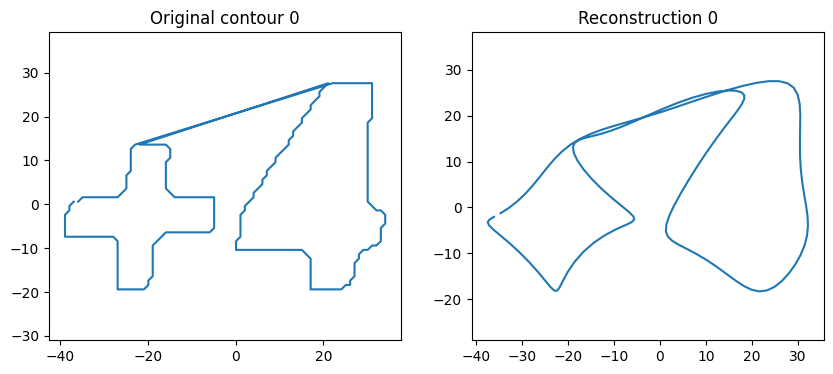

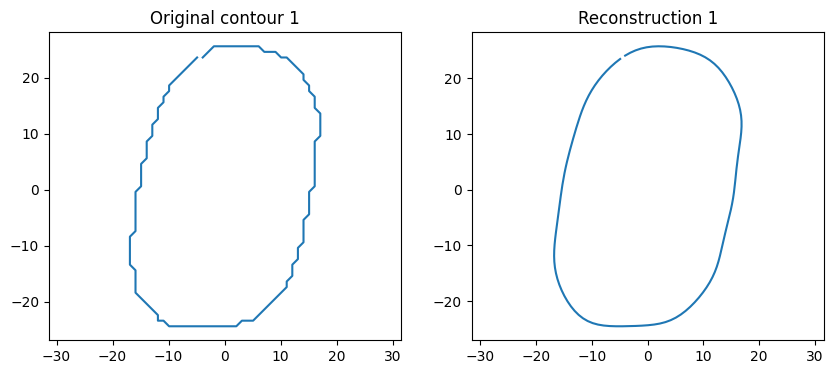

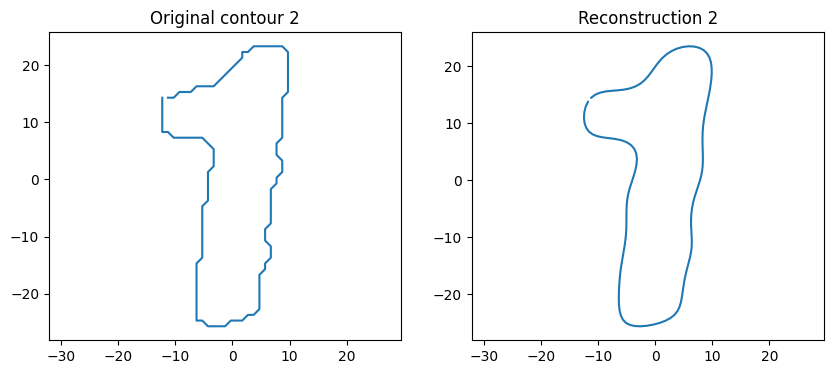

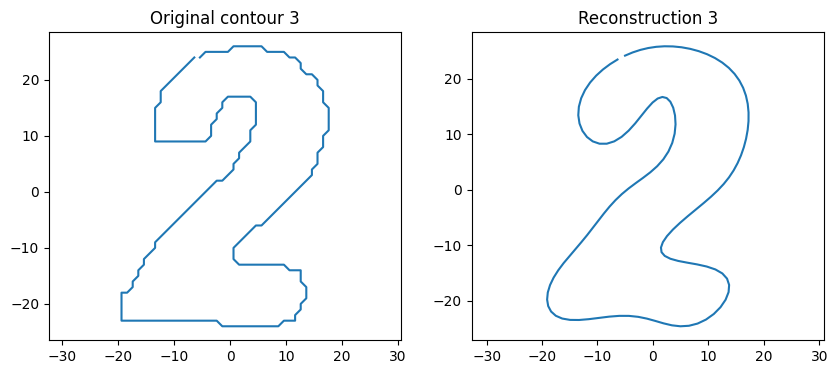

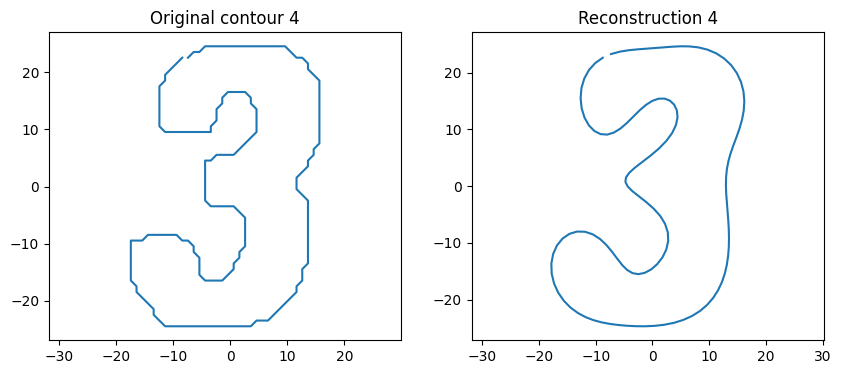

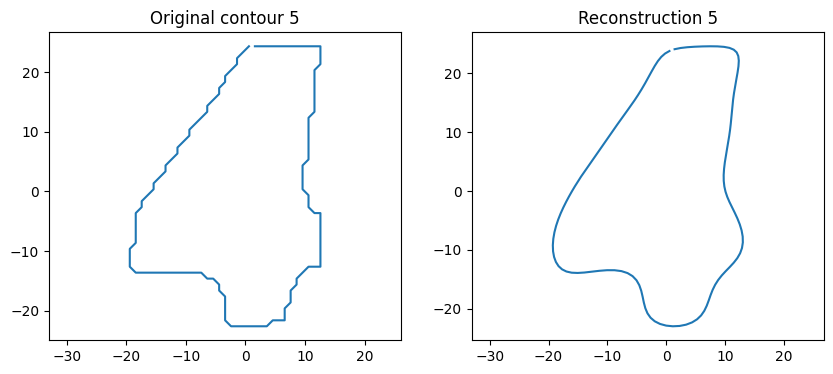

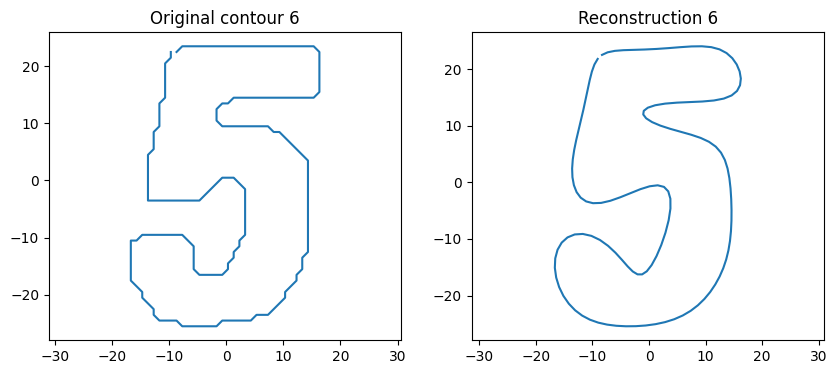

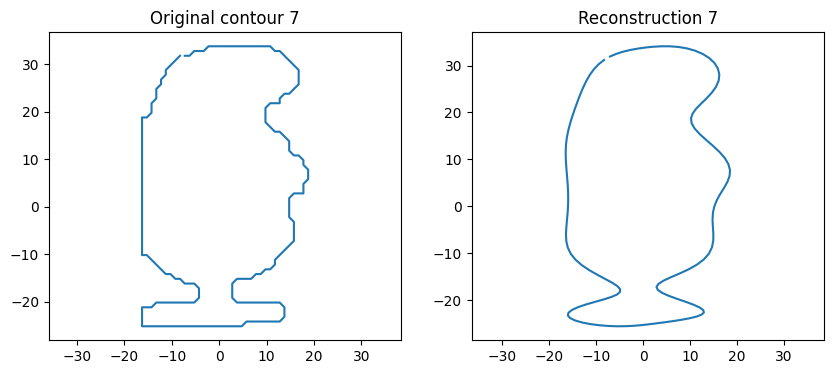

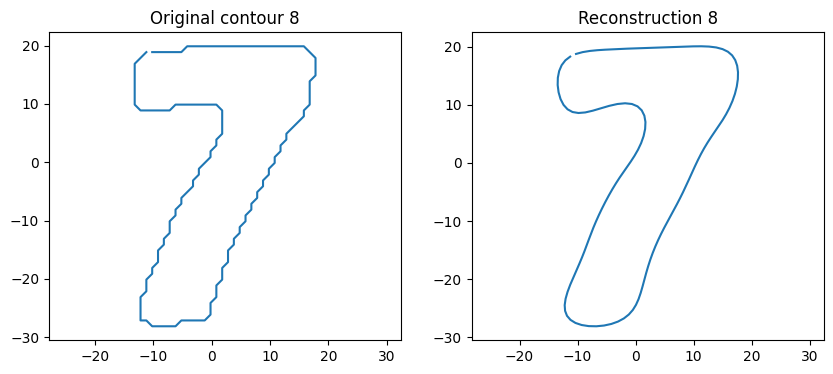

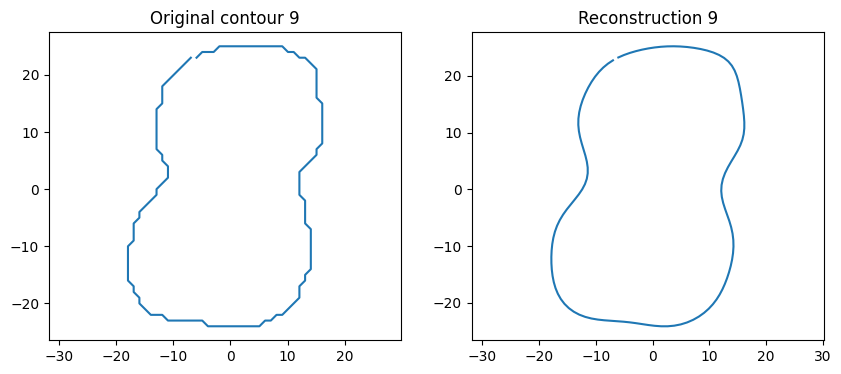

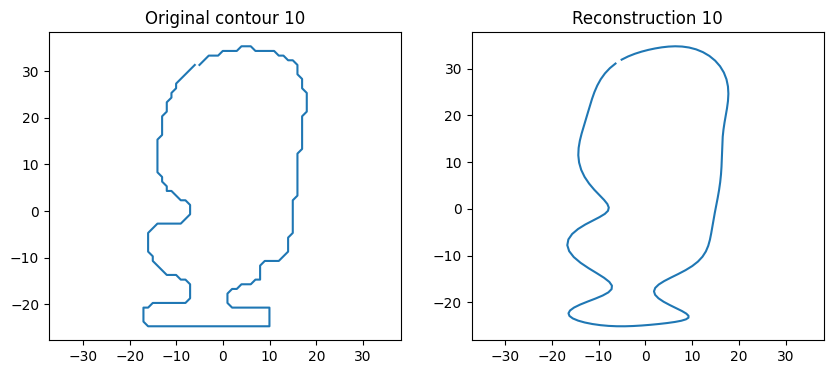

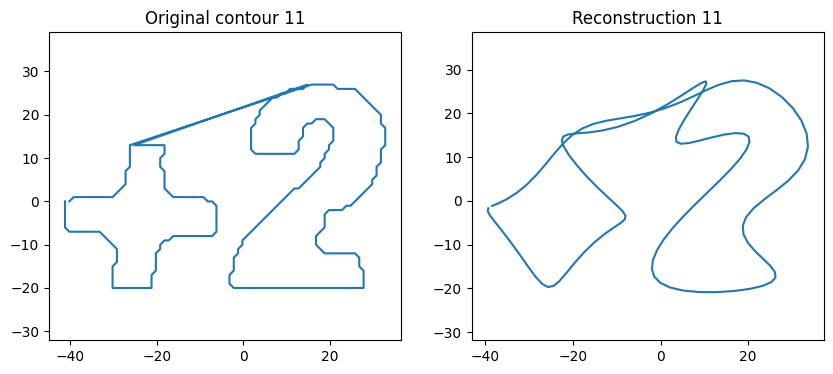

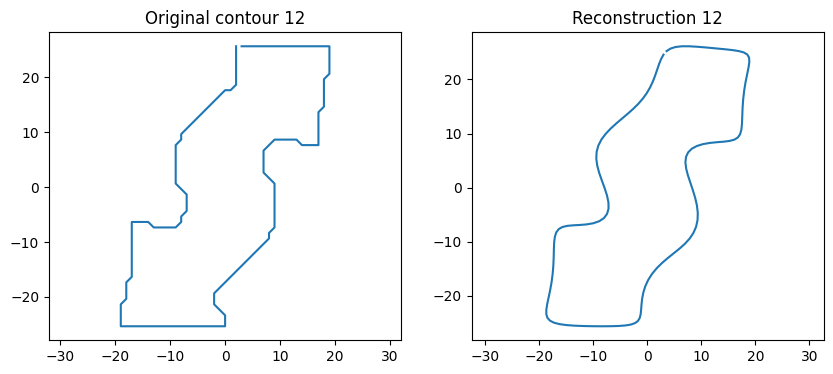

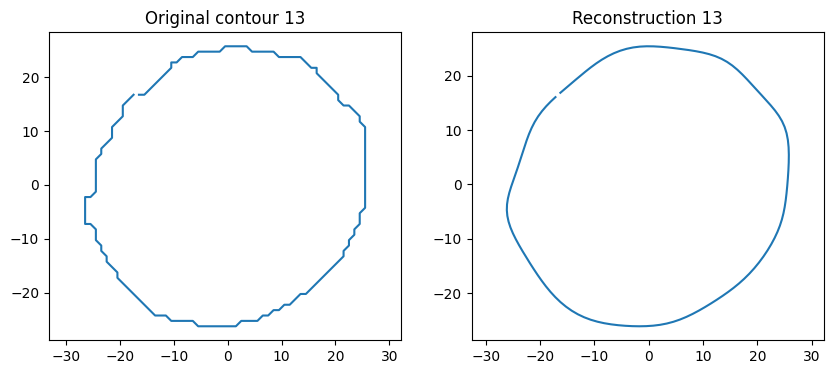

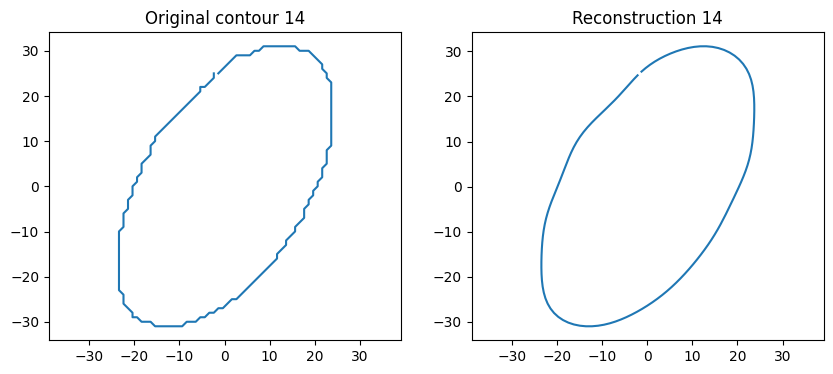

In [121]:
plot_all_checks(clean_contours, descriptors)

## Test

In [174]:
blue_indices = (
    list(range(0, 13)) +
    list(range(27, 40)) +
    list(range(41, 54))
)
blue_cards = [cards[i] for i in blue_indices]

In [175]:
def build_test_set(cards_subset, n_points=128, n_coeffs=20):

    test_descriptors = []
    test_labels = []

    for name, card_rgb in cards_subset:

        roi = extract_top_left_corner(card_rgb)
        cropped = dynamic_corner_crop(roi, threshold=200)

        processed = preprocess_symbol(cropped)

        contour = find_contour_uno(processed)

        if contour.size == 0:
            continue

        contour = normalize_contour(contour, processed.shape)

        F = fourier_descriptors(contour, n_points, n_coeffs)

        test_descriptors.append(F)
        test_labels.append(name)

    return np.array(test_descriptors), test_labels

In [176]:
def descriptor_distance(F1, F2):

    F1 = F1 / (np.linalg.norm(F1) + 1e-8)
    F2 = F2 / (np.linalg.norm(F2) + 1e-8)

    return np.linalg.norm(F1 - F2)

In [177]:
def parse_label(label):
    """
    Extract only the symbol identity (ignore color).
    """
    return label.split("_")[-1]

In [178]:
def test_on_blue_cards(train_descriptors, train_labels,
                       test_descriptors, test_labels):

    correct = 0

    for i, F_test in enumerate(test_descriptors):

        best_j = None
        best_d = 1e9

        for j, F_train in enumerate(train_descriptors):

            d = descriptor_distance(F_test, F_train)

            if d < best_d:
                best_d = d
                best_j = j

        pred_label = parse_label(train_labels[best_j])
        true_label = parse_label(test_labels[i])

        print(f"{test_labels[i]} → predicted: {train_labels[best_j]} | dist={best_d:.4f}")

        if pred_label == true_label:
            correct += 1

    print("\nAccuracy (ignoring color):", correct / len(test_descriptors))

In [179]:
test_descriptors, test_labels = build_test_set(blue_cards)

test_on_blue_cards(
    descriptors,
    labels,
    test_descriptors,
    test_labels
)

b_0.png → predicted: g_8.png | dist=0.2555
b_2.png → predicted: g_2.png | dist=0.1105
b_3.png → predicted: g_9.png | dist=0.4010
b_4.png → predicted: g_4.png | dist=0.0367
b_5.png → predicted: g_5.png | dist=0.2438
b_6.png → predicted: g_6.png | dist=0.1664
b_7.png → predicted: g_7.png | dist=0.0441
b_8.png → predicted: g_8.png | dist=0.0528
b_9.png → predicted: g_9.png | dist=0.1112
b_draw_2.png → predicted: g_draw_2.png | dist=0.0583
b_reverse.png → predicted: g_reverse.png | dist=0.0801
b_skip.png → predicted: g_skip.png | dist=0.1421
r_0.png → predicted: g_8.png | dist=0.2203
r_1.png → predicted: g_1.png | dist=0.1387
r_2.png → predicted: g_2.png | dist=0.1853
r_3.png → predicted: g_3.png | dist=0.1200
r_4.png → predicted: g_4.png | dist=0.0911
r_5.png → predicted: g_5.png | dist=0.0706
r_6.png → predicted: g_6.png | dist=0.1539
r_7.png → predicted: g_7.png | dist=0.0560
r_8.png → predicted: g_8.png | dist=0.0531
r_9.png → predicted: g_9.png | dist=0.0928
r_draw_2.png → predicted: 